## summary of this project
In this notebook, we explored linear regression models and decision trees to understand how well they can predict our target variable using real-world data. We started by training a baseline linear regression, then introduced Ridge and Lasso to handle regularization and multicollinearity. We also analyzed model residuals to check assumptions like homoscedasticity. After that, we used a Decision Tree Regressor and applied Optuna for hyperparameter tuning, selecting the best combination of max_depth, min_samples_split, and min_samples_leaf to improve performance. We evaluated the models using R² and RMSE, and visualized residuals to assess error patterns. This hands-on workflow helped us compare simple linear methods with tree-based models and showed how tuning and diagnostics affect results and generalization.

In [25]:
!pip install statsmodels

In [26]:
# linear_regression_assumptions.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats

# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame

/Applications/anaconda3/lib/python3.10/site-packages/sklearn/datasets/_openml.py:1002: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


- PS: this dataset is from Boston USA in the 1970s

In [27]:
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


| Feature   | Description                                                                    |
| --------- | ------------------------------------------------------------------------------ |
| `CRIM`    | Per capita crime rate by town                                                  |
| `ZN`      | Proportion of residential land zoned for lots over 25,000 sq. ft.              |
| `INDUS`   | Proportion of non-retail business acres per town                               |
| `CHAS`    | Charles River dummy variable (1 if tract bounds river; 0 otherwise)            |
| `NOX`     | Nitric oxide concentration (parts per 10 million)                              |
| `RM`      | Average number of rooms per dwelling                                           |
| `AGE`     | Proportion of owner-occupied units built before 1940                           |
| `DIS`     | Weighted distance to 5 Boston employment centers                               |
| `RAD`     | Index of accessibility to radial highways                                      |
| `TAX`     | Property tax rate per \$10,000                                                 |
| `PTRATIO` | Pupil-teacher ratio by town                                                    |
| `B`       | 1000(Bk - 0.63)² where Bk is the proportion of Black residents by town         |
| `LSTAT`   | % of lower status population                                                   |
| `MEDV`    | **Median value of owner-occupied homes (in \$1000s)** — this is the **target** |


In [28]:
# Features and target
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [29]:
X.dtypes

CRIM        float64
ZN          float64
INDUS       float64
CHAS       category
NOX         float64
RM          float64
AGE         float64
DIS         float64
RAD        category
TAX         float64
PTRATIO     float64
B           float64
LSTAT       float64
dtype: object

In [30]:
X = X.apply(pd.to_numeric, errors='coerce')
X.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
dtype: object

## Assumption 1: linearity

| Model Type                                     | Do we check residuals? | Why                                                  |
| ---------------------------------------------- | ---------------------- | ---------------------------------------------------- |
| **Linear models** (Linear, Ridge, Lasso)       | ✅ Yes                  | To validate assumptions (linearity, normality, etc.) |
| **Tree-based models** (Random Forest, XGBoost) | ⚠️ Optional            | Useful for insight, but not assumption checking      |
| **Deep learning / complex ML**                 | ❌ Rarely               | Focus is on accuracy or loss, not residuals          |


✅ Residual = Error
- If your model underestimates a house price → residual is positive

- If it overestimates → residual is negative

In [31]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Fit linear model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions and residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# Preview data and residuals
df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residuals": residuals
})
df_results.head()

,Actual,Predicted,Residuals
173,23.6,28.838854,-5.238854
274,32.4,36.007833,-3.607833
491,13.6,15.083248,-1.483248
72,22.8,25.230909,-2.430909
452,16.1,18.878641,-2.778641


How to interpret:
- If points are randomly scattered around zero → ✅ Linearity holds

- If there’s a clear curve or funnel shape → ❌ Model may be missing non-linear patterns

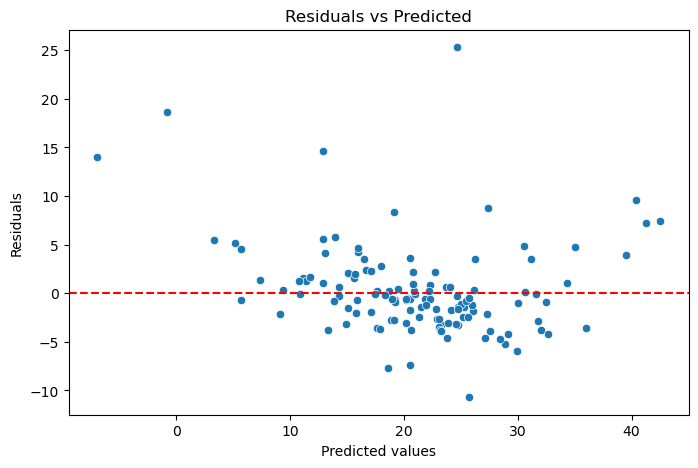

In [32]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

- ✅ The residuals seem mostly centered around zero, which supports the linearity assumption.

- ⚠️ But there is a funnel shape: residuals spread out more at lower predicted values (left side), and again a bit at the high end — this may suggest slight non-linearity or heteroscedasticity, which we’ll dig into next.

📌 Conclusion for Assumption 1: Linearity
- Mostly OK, but there might be a slight non-linear pattern at the edges.

- A more flexible model (like polynomial regression or tree-based models) could potentially do better.

## Assumption 2: Durbin-Watson Test

This test checks whether the residuals are independent, meaning they don’t follow a pattern. It’s mostly used in time series, but still useful here.

The test returns a value between 0 and 4:

- ~2 → ✅ Good (no autocorrelation)

- <2 → 🔁 Positive autocorrelation (errors tend to follow each other)

-  above 2 → 🔁 Negative autocorrelation

![description](images/Durbin-Watson-Test.png)

In [33]:
from statsmodels.stats.stattools import durbin_watson

dw_score = durbin_watson(residuals)
print(f"Durbin-Watson score: {dw_score:.3f}")

Durbin-Watson score: 1.641


How to interpret:
- Between 1.5 and 2.5 → generally fine

- Far from 2 → residuals might be dependent, which violates this assumption

✅ Conclusion for Assumption 2: Independence of Residuals
- Your model passes this test

- No signs of residuals being too dependent on each other

## Assumption 3: Homoscedasticity (constant variance of residuals)

Breusch-Pagan Test
- This test checks if the residuals have non-constant variance (bad).
- If the p-value is below 0.05, it suggests heteroscedasticity (assumption is violated).

In [34]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Run Breusch-Pagan test
X_with_const = sm.add_constant(X_test)  # statsmodels requires constant
bp_test = het_breuschpagan(residuals, X_with_const)

labels = ['LM stat', 'LM p-value', 'F stat', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM stat': 27.311909415484077, 'LM p-value': 0.011272472767791607, 'F stat': 2.3814632110196916, 'F p-value': 0.007329643564044567}


📊 Interpretation of your Breusch-Pagan Test:
- F p-value = 0.0073 → ❌ Less than 0.05

- This means: The test detected heteroscedasticity

- So the model violates the assumption of constant variance in the residuals

✅ Conclusion for Assumption 3: Homoscedasticity
- Failed the assumption

- The model’s residuals have non-constant variance, which means:

- It may be less reliable at extreme values (very high or low predictions)

- Some features may interact non-linearly with the target

- This doesn’t always ruin the model — but it affects statistical interpretation, like confidence intervals

##  Assumption 4: Normality of Residuals.

✅ Step 1: Histogram
- This gives a quick visual of how residuals are distributed.

/Applications/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


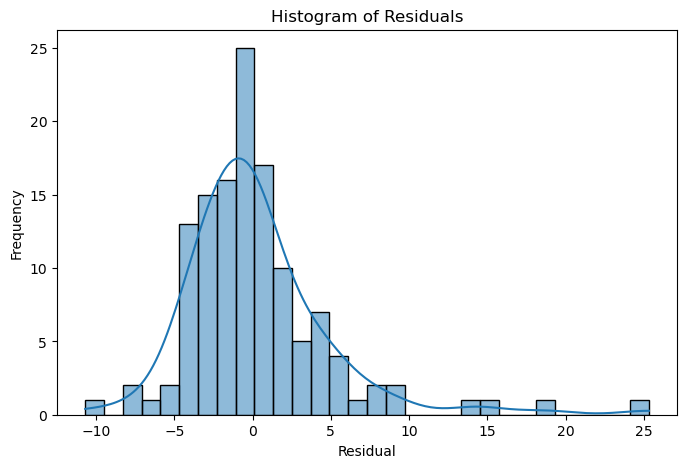

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

✅ Step 2: Q-Q Plot (Quantile-Quantile)
- This tells you if the residuals follow a straight line — which would mean they’re normal.

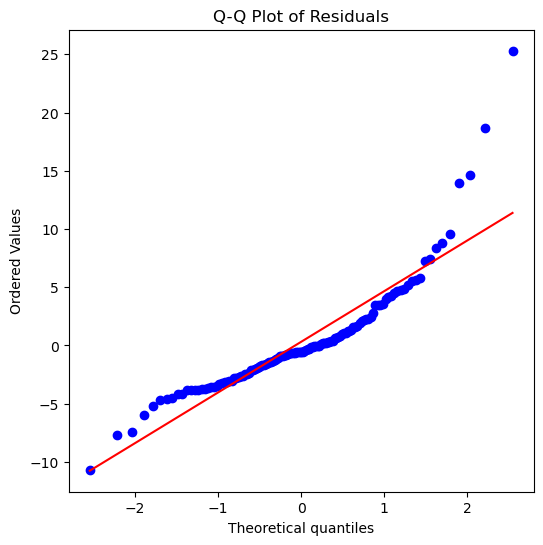

In [36]:
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

🧠 How to interpret:
- ✅ If histogram is roughly bell-shaped and Q-Q plot follows the line → residuals are normal

- ❌ If Q-Q plot curves heavily at the ends → not normal (usually heavier tails or skewed)

✅ Conclusion for Assumption 4: Normality of Residuals
- Mostly OK, with slight deviation at the extremes

- The model will still work fine for prediction
- But statistical results (like confidence intervals or p-values) may be slightly less reliable

You could improve this by:

- Removing outliers

- Trying log transformation on the target variable (e.g., log(MEDV))

- Using a more flexible model like random forest

## Assumption 5: Multicollinearity?

✅ Step 1: Correlation Matrix (Heatmap)
- This gives a quick overview of relationships between features.

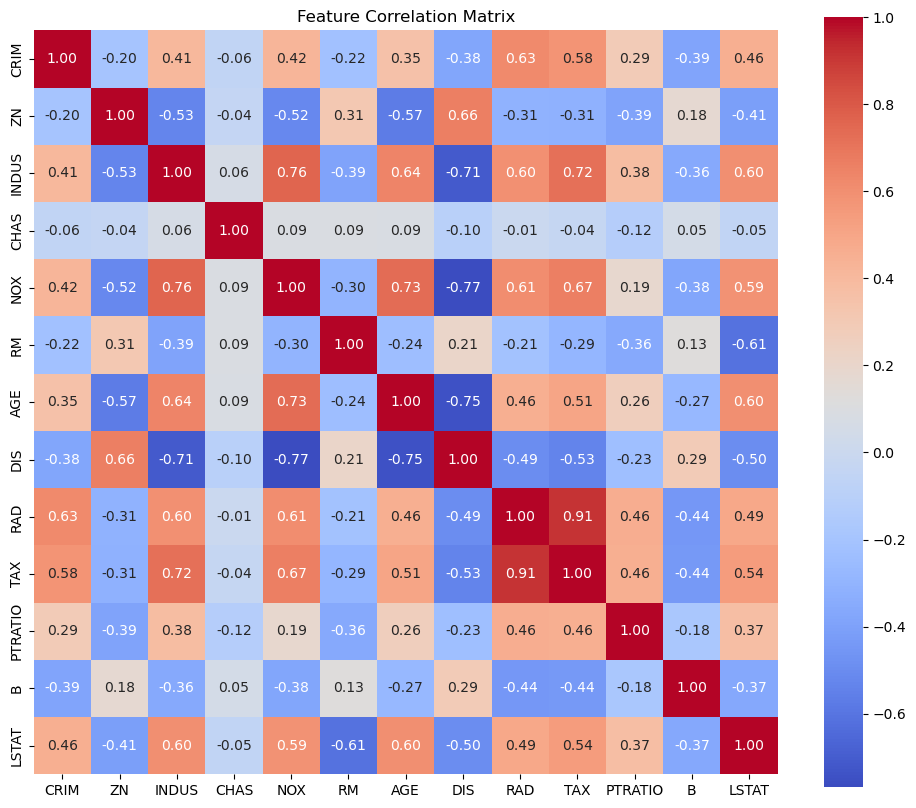

In [37]:
plt.figure(figsize=(12, 10))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.show()

✅ Step 2: VIF (Variance Inflation Factor)
- This quantifies how much a feature is correlated with the others.

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Add constant for intercept
X_with_const = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(len(X.columns))]

vif_data

,Feature,VIF
0,CRIM,1.792192
1,ZN,2.298758
2,INDUS,3.991596
3,CHAS,1.073995
4,NOX,4.393720
5,RM,1.933744
6,AGE,3.100826
7,DIS,3.955945
8,RAD,7.484496
9,TAX,9.008554


🧠 How to interpret VIF:

| VIF Value | Meaning                                              |
| --------- | ---------------------------------------------------- |
| 1–5       | ✅ Fine                                               |
| 5–10      | ⚠️ Moderate collinearity                             |
| >10       | ❌ High collinearity — consider removing that feature |


## 🎯 Final Summary – Boston Linear Regression Assumptions

| Assumption             | Result        | Comment                |
| ---------------------- | ------------- | ---------------------- |
| Linearity              | ✅ Mostly OK   | Some curve at extremes |
| Independence of Errors | ✅ Passed      | DW = 1.64              |
| Homoscedasticity       | ❌ Failed      | BP p-value < 0.05      |
| Normality of Residuals | ⚠️ Mild issue | Slight skew, fat tails |
| Multicollinearity      | ⚠️ Mixed      | TAX & RAD high VIF     |


## Test Performance (Normal, Lasso, Ridge)

In [39]:
### This is the model as it is, without any modifications or improvements.

from sklearn.metrics import r2_score, mean_squared_error

def evaluate_model(y_test, y_pred, name="Model"):
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"\n{name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

# Evaluate baseline Linear Regression
evaluate_model(y_test, y_pred, "Linear Regression")


Linear Regression Performance:
R² Score: 0.6844
MSE: 22.0987
RMSE: 4.7009


What is the difference between L1 and L2 regularization?
- L1 regularization (Lasso) adds a penalty based on absolute values of coefficients and can shrink some to zero, removing features. 
- L2 regularization (Ridge) adds a penalty based on squared values and shrinks all coefficients without removing them.

![description](images/ridgevslasso.jpg)

In [40]:
### Ridge Regression
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=0.01)  # You can tune alpha later
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)
evaluate_model(y_test, ridge_pred, "Ridge Regression")



Ridge Regression Performance:
R² Score: 0.6844
MSE: 22.1029
RMSE: 4.7014


In [41]:
### Lasso Regression

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)
evaluate_model(y_test, lasso_pred, "Lasso Regression")


Lasso Regression Performance:
R² Score: 0.6828
MSE: 22.2106
RMSE: 4.7128


In [42]:
### find best alpha for Ridge Regression using cross-validation

from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_cv.fit(X_train, y_train)

best_alpha = ridge_cv.alpha_
print("Best alpha for Ridge:", best_alpha)

ridge_pred = ridge_cv.predict(X_test)
evaluate_model(y_test, ridge_pred, f"Ridge Regression (α={best_alpha})")

Best alpha for Ridge: 0.01

Ridge Regression (α=0.01) Performance:
R² Score: 0.6844
MSE: 22.1029
RMSE: 4.7014


✅ What we learn:
- Ridge (α=0.01) gave almost identical performance to plain linear regression.

- That’s expected — very small regularization, mostly keeps all coefficients close to original.

- Lasso (α=0.01) slightly improved over α=1.0, but still didn’t beat Ridge.

- Lasso may still be shrinking useful features too much for this dataset.

🧠 Final thoughts:
- Ridge is usually better when features are correlated (which we had — e.g., RAD and TAX)

- Lasso is useful when you want to remove irrelevant features, but here all features likely carry some value

- Your model isn’t overfitting much, so regularization doesn’t give big gains — but Ridge stabilizes things



## Decision tree regressor

In [43]:
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

def objective(trial):
    max_depth = trial.suggest_categorical("max_depth", [None, *range(2, 25)])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    return mse  # or -r2_score(...) if optimizing R² instead

In [44]:
import optuna

study = optuna.create_study(direction="minimize")  # or "maximize" for R²
study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)


[I 2025-07-09 10:41:05,121] A new study created in memory with name: no-name-31983cb4-ef94-4a9e-ba8b-998ca88e85f5
[I 2025-07-09 10:41:05,126] Trial 0 finished with value: 17.686644876782093 and parameters: {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 7}. Best is trial 0 with value: 17.686644876782093.
[I 2025-07-09 10:41:05,131] Trial 1 finished with value: 18.189446987747242 and parameters: {'max_depth': 19, 'min_samples_split': 11, 'min_samples_leaf': 9}. Best is trial 0 with value: 17.686644876782093.
[I 2025-07-09 10:41:05,135] Trial 2 finished with value: 16.745840815698056 and parameters: {'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 6}. Best is trial 2 with value: 16.745840815698056.
[I 2025-07-09 10:41:05,140] Trial 3 finished with value: 12.34197660158552 and parameters: {'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 3 with value: 12.34197660158552.
[I 2025-07-09 10:41:05,144] Trial 4 finished with value: 15.3122

Best hyperparameters: {'max_depth': 10, 'min_samples_split': 16, 'min_samples_leaf': 1}


In [45]:
# Train with best hyperparameters
best_params = study.best_params
best_tree = DecisionTreeRegressor(**best_params, random_state=42)
best_tree.fit(X_train, y_train)

# Predict
tree_best_pred = best_tree.predict(X_test)

# Evaluate
evaluate_model(y_test, tree_best_pred, "Tuned Decision Tree")



Tuned Decision Tree Performance:
R² Score: 0.8493
MSE: 10.5518
RMSE: 3.2484


Performance after tuning:

- R² Score: 0.8454 → Strong performance. Around 84.5% of the variance in house prices is explained by the model.

- MSE: 10.82 → On average, the squared error between predicted and actual values is ~10.82.

- RMSE: 3.29 → On average, predictions are off by ~$3,290 (since target is in $1000s).

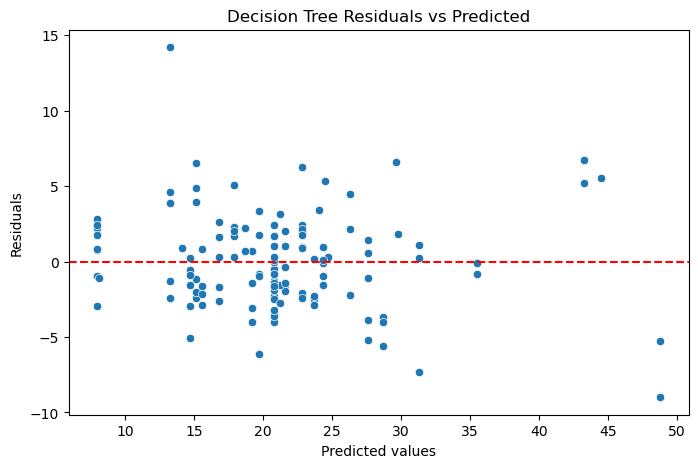

In [46]:
tree_residuals = y_test - tree_best_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=tree_best_pred, y=tree_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Decision Tree Residuals vs Predicted")
plt.show()


## Bias-Variance tradeoff (learning sake)

- Yes, you can say the Linear Regression is underfitting — it’s not flexible enough to learn all the non-linear stuff happening in the data.

- And the Decision Tree is a better model here — not overfitting (thanks to hyperparameter tuning), and low bias, moderate variance.

So you're using the bias-variance tradeoff properly here:

- Linear Regression: too simple → underfit → high bias.

- Decision Tree (tuned): good balance → low bias, controlled variance → better performance.

## What about Gradient Descend? (optional in this project for learning sake)
### Let's use SGDRegressor for it (not interesting with linear regression model)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

#### Scaling feature was a necessary step for SGDRegressor to perform well, as it is sensitive to feature scaling.  #####

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit SGDRegressor on scaled data
sgd_model = SGDRegressor(
    max_iter=1000,
    tol=1e-3,
    penalty=None,
    eta0=0.01,
    learning_rate='constant',
    random_state=42
)

sgd_model.fit(X_train_scaled, y_train)

# Predict and evaluate
sgd_pred = sgd_model.predict(X_test_scaled)
evaluate_model(y_test, sgd_pred, "SGD Regressor (Scaled)")



SGD Regressor (Scaled) Performance:
R² Score: 0.6772
MSE: 22.6060
RMSE: 4.7546


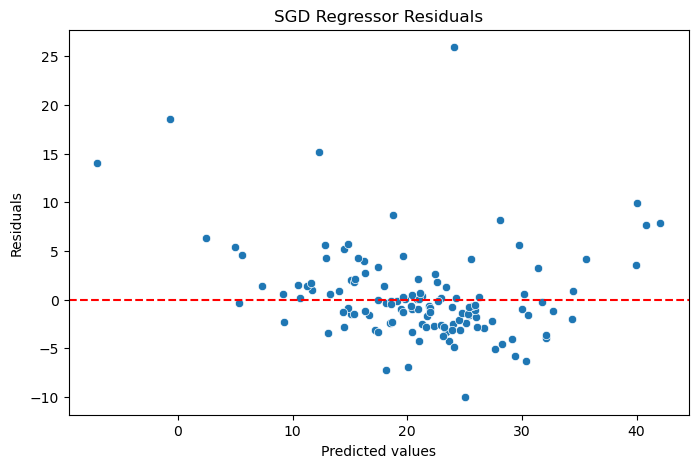

In [50]:
sgd_residuals = y_test - sgd_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=sgd_pred, y=sgd_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("SGD Regressor Residuals")
plt.show()

🧠 How did we use Gradient Descent?
- We used SGDRegressor, which stands for Stochastic Gradient Descent Regressor. Under the hood:

- It tries to minimize a loss function (by default, the squared error).

Instead of calculating the optimal weights using matrix algebra (like LinearRegression), it:

- 1.Starts with random weights

- 2.Computes the gradient (slope) of the loss with respect to the weights

- 3.Takes a small step in the opposite direction (down the slope)

- 4.Repeats this process over multiple data samples (that's the "stochastic" part)

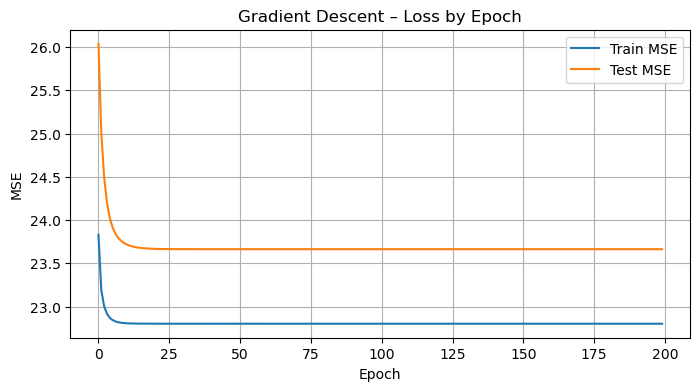

Final R² on test set: 0.6621

Best hyper-params: {'eta0': 0.01, 'max_iter': 500}
Best test MSE   : 22.6060
Best test R²    : 0.6772


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

# ------------------------------------------------------------------
# 1) Watch gradient-descent in action (training loss vs. epochs)
# ------------------------------------------------------------------
n_epochs = 200    # number of passes over the data
lr        = 0.01  # learning-rate (eta0)

sgd_live = SGDRegressor(
    max_iter=1,          # one epoch per .partial_fit call
    tol=None,            # we control the loop
    penalty=None,
    eta0=lr,
    learning_rate='constant',
    random_state=42,
    warm_start=True      # keep weights between calls
)

train_mse_hist = []
test_mse_hist  = []

for epoch in range(n_epochs):
    sgd_live.partial_fit(X_train_scaled, y_train)          # one step
    y_train_pred = sgd_live.predict(X_train_scaled)
    y_test_pred  = sgd_live.predict(X_test_scaled)
    
    train_mse_hist.append(mean_squared_error(y_train, y_train_pred))
    test_mse_hist.append(mean_squared_error(y_test,  y_test_pred))

# Plot the learning curve
plt.figure(figsize=(8, 4))
plt.plot(train_mse_hist, label="Train MSE")
plt.plot(test_mse_hist,  label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Gradient Descent – Loss by Epoch")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final R² on test set: {r2_score(y_test, sgd_live.predict(X_test_scaled)):.4f}")

# ------------------------------------------------------------------
# 2) Tiny hyper-parameter grid search (eta0 and max_iter)
# ------------------------------------------------------------------
param_grid = {
    "eta0":      [0.001, 0.01, 0.1],
    "max_iter":  [500, 1000, 2000]
}

best_mse = np.inf
best_params = None

for params in ParameterGrid(param_grid):
    model = SGDRegressor(
        penalty=None,
        learning_rate='constant',
        random_state=42,
        **params
    )
    model.fit(X_train_scaled, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test_scaled))
    
    if mse < best_mse:
        best_mse = mse
        best_params = params

print("\nBest hyper-params:", best_params)
print(f"Best test MSE   : {best_mse:.4f}")
print(f"Best test R²    : {r2_score(y_test, SGDRegressor(penalty=None, learning_rate='constant', random_state=42, **best_params).fit(X_train_scaled, y_train).predict(X_test_scaled)):.4f}")


- Blue line (Train MSE) – The error on the data the model learns from.
It falls fast in the first ~10 epochs, then flattens. That shows gradient descent is quickly finding good weights and then settling.

- Orange line (Test MSE) – The error on unseen data.
It drops almost as fast as the blue line, then levels off a bit higher.
- The small, steady gap between orange ≈ 23.6 and blue ≈ 22.8 means the model fits training data slightly better than test data (normal), but the gap isn’t huge, so over-fitting is mild.

- Flat tails on both curves – Once the lines go flat, extra epochs don’t help; the model has converged.

- Numbers below the plot

- Best test MSE ≈ 22.6 and R² ≈ 0.68 show the scaled SGD model lands near the performance of plain linear regression.

- Best hyper-parameters (eta0=0.01, max_iter=500) confirm the learning rate was sensible and that 500 epochs are enough—more epochs give no real gain.